In [ ]:
import subprocess, sys
def _pip(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])
_pip(["pandas-ta-classic", "yfinance", "matplotlib"])

import numpy as np
import pandas as pd
import yfinance as yf
import pandas_ta_classic as ta
import matplotlib.pyplot as plt
from itertools import product

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

TICKER, START, END = "AAPL", "2018-01-01", "2024-12-31"
raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
df = (raw.rename(columns=str.lower)
         [["open", "high", "low", "close", "volume"]]
         .dropna()
         .copy())
df.index.name = "date"
print(f"[data] {TICKER}: {len(df)} rows  "
      f"{df.index.min().date()} → {df.index.max().date()}")

print("[lib]  Categories:", list(ta.Category.keys()))
for cat in ("momentum", "overlap", "trend", "volatility", "volume"):
    names = ta.Category.get(cat, [])
    print(f"[lib]  {cat:<11} ({len(names):>3}): "
          f"{', '.join(names[:8])}{' ...' if len(names) > 8 else ''}")

In [ ]:
df.ta.sma(length=20,  append=True)
df.ta.sma(length=50,  append=True)
df.ta.ema(length=200, append=True)
df.ta.rsi(length=14,  append=True)
df.ta.atr(length=14,  append=True)
df.ta.macd(append=True)
df.ta.bbands(length=20, std=2.0, append=True)

my_strategy = ta.Strategy(
    name="AdvancedDemo",
    description="Trend + momentum + volume + volatility in one shot",
    ta=[
        {"kind": "hma",   "length": 30},
        {"kind": "adx",   "length": 14},
        {"kind": "aroon", "length": 14},
        {"kind": "stoch", "k": 14, "d": 3},
        {"kind": "obv"},
        {"kind": "mfi",   "length": 14},
        {"kind": "willr", "length": 14},
        {"kind": "cci",   "length": 20},
        {"kind": "kc",    "length": 20, "scalar": 2},
    ],
)
df.ta.strategy(my_strategy)
print(f"[strat] DataFrame now has {df.shape[1]} columns")

df["dist_ema200_pct"] = (df["close"] / df["EMA_200"] - 1.0) * 100

df.ta.cdl_doji(append=True)
df.ta.cdl_inside(append=True)
doji_col = next((c for c in df.columns if c.startswith("CDL_DOJI")), None)
print(f"[cdl]  Doji days detected: {int((df[doji_col] == 100).sum())}")

In [ ]:
weekly = (df[["open", "high", "low", "close", "volume"]]
          .resample("W-FRI")
          .agg({"open":"first","high":"max","low":"min","close":"last","volume":"sum"})
          .dropna())
weekly["RSI_W_14"] = ta.rsi(weekly["close"], length=14)
df = df.join(weekly[["RSI_W_14"]])
df["RSI_W_14"] = df["RSI_W_14"].ffill().shift(1)

trend     = df["SMA_20"] > df["SMA_50"]
mom_cross = (df["RSI_14"] > 50) & (df["RSI_14"].shift(1) <= 50)
mtf_ok    = df["RSI_W_14"] > 50
exit_cond = (df["RSI_14"] < 45) | (df["SMA_20"] < df["SMA_50"])

position = np.zeros(len(df), dtype=int)
in_pos = False
for i in range(len(df)):
    if not in_pos and trend.iat[i] and mom_cross.iat[i] and bool(mtf_ok.iat[i]):
        in_pos = True
    elif in_pos and exit_cond.iat[i]:
        in_pos = False
    position[i] = 1 if in_pos else 0
df["pos"] = position

df["ret"]       = df["close"].pct_change().fillna(0.0)
df["strat_ret"] = df["pos"].shift(1).fillna(0) * df["ret"]

In [ ]:
def perf(returns, ppy=252):
    r = returns.dropna()
    if len(r) == 0 or r.std() == 0:
        return {}
    cum  = (1 + r).cumprod()
    cagr = cum.iloc[-1] ** (ppy / len(r)) - 1
    vol  = r.std() * np.sqrt(ppy)
    sharpe = (r.mean() / r.std()) * np.sqrt(ppy)
    downside = r[r < 0].std() * np.sqrt(ppy)
    sortino  = (r.mean() * ppy) / downside if downside > 0 else np.nan
    mdd  = (cum / cum.cummax() - 1).min()
    nz   = r[r != 0]
    win  = (nz > 0).mean() if len(nz) else 0.0
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sharpe,
            "Sortino": sortino, "MaxDD": mdd, "WinRate": win,
            "FinalEquity": cum.iloc[-1]}

summary = pd.DataFrame({
    "Buy & Hold": perf(df["ret"]),
    "Strategy":   perf(df["strat_ret"]),
}).T
print("\n[perf] ----------------------------------------")
print(summary.round(4))

def quick_bt(prices, fast, slow, rsi_thr=50):
    if fast >= slow:
        return None
    d = prices.copy()
    d["SMAf"] = ta.sma(d["close"], length=fast)
    d["SMAs"] = ta.sma(d["close"], length=slow)
    d["RSI"]  = ta.rsi(d["close"], length=14)
    sig = ((d["SMAf"] > d["SMAs"]) & (d["RSI"] > rsi_thr)).astype(int)
    sret = sig.shift(1).fillna(0) * d["close"].pct_change().fillna(0)
    return perf(sret)

prices = df[["open", "high", "low", "close", "volume"]]
rows = []
for fast, slow in product([5, 10, 20, 30], [50, 100, 150, 200]):
    m = quick_bt(prices, fast, slow)
    if m:
        rows.append({"fast": fast, "slow": slow, **m})
sweep = (pd.DataFrame(rows)
           .sort_values("Sharpe", ascending=False)
           .reset_index(drop=True))
print("\n[sweep] Top 5 (fast SMA, slow SMA) by Sharpe:")
print(sweep.head().round(4))

[data] AAPL: 1760 rows  2018-01-02 → 2024-12-30
[lib]  Categories: ['performance', 'volume', 'candles', 'volatility', 'trend', 'cycles', 'statistics', 'overlap', 'momentum']
[lib]  momentum    ( 52): ao, apo, bias, bop, brar, cci, cfo, cg ...
[lib]  overlap     ( 46): alma, avgprice, dema, ema, fwma, hilo, hl2, hlc3 ...
[lib]  trend       ( 26): adx, adxr, amat, aroon, chop, cksp, cpr, decay ...
[lib]  volatility  ( 18): aberration, accbands, atr, avolume, bbands, ce, cvi, donchian ...
[lib]  volume      ( 20): ad, adosc, aobv, cmf, efi, emv, eom, kvo ...
[strat] DataFrame now has 34 columns
[cdl]  Doji days detected: 250

[perf] ----------------------------------------
              CAGR     Vol  Sharpe  Sortino   MaxDD  WinRate  FinalEquity
Buy & Hold  0.2992  0.3054  1.0102   1.4014 -0.3852   0.5390       6.2234
Strategy    0.0956  0.1290  0.7721   0.5663 -0.1594   0.5514       1.8916

[sweep] Top 5 (fast SMA, slow SMA) by Sharpe:
   fast  slow    CAGR     Vol  Sharpe  Sortino   Max

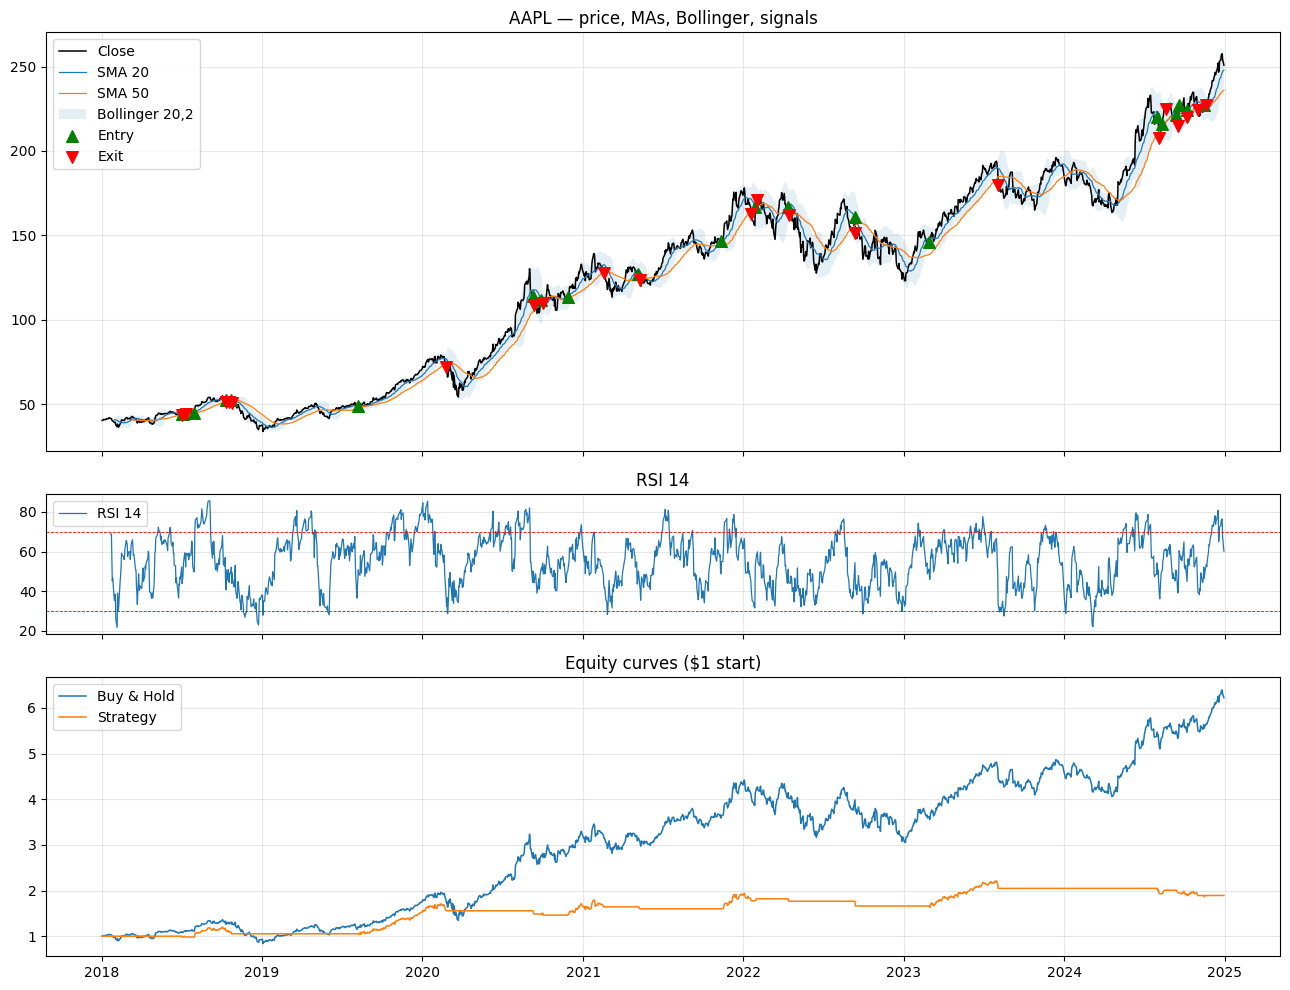


Tweak TICKER, the Strategy list, or the sweep grid to keep exploring.


In [3]:
entries = df.index[(df["pos"].diff() == 1)]
exits   = df.index[(df["pos"].diff() == -1)]

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(13, 10), sharex=True,
    gridspec_kw={"height_ratios": [3, 1, 2]},
)
ax1.plot(df.index, df["close"],  lw=1.1, color="black", label="Close")
ax1.plot(df.index, df["SMA_20"], lw=0.9, label="SMA 20")
ax1.plot(df.index, df["SMA_50"], lw=0.9, label="SMA 50")
bbu, bbl = "BBU_20_2.0", "BBL_20_2.0"
if bbu in df and bbl in df:
    ax1.fill_between(df.index, df[bbl], df[bbu], alpha=0.12, label="Bollinger 20,2")
ax1.scatter(entries, df.loc[entries, "close"], marker="^", s=70,
            color="green", zorder=5, label="Entry")
ax1.scatter(exits,   df.loc[exits,   "close"], marker="v", s=70,
            color="red",   zorder=5, label="Exit")
ax1.set_title(f"{TICKER} — price, MAs, Bollinger, signals")
ax1.legend(loc="upper left"); ax1.grid(alpha=0.3)

ax2.plot(df.index, df["RSI_14"], lw=0.9, label="RSI 14")
ax2.axhline(70, color="red",   ls="--", lw=0.6)
ax2.axhline(30, color="green", ls="--", lw=0.6)
ax2.set_title("RSI 14"); ax2.legend(loc="upper left"); ax2.grid(alpha=0.3)

ax3.plot(df.index, (1 + df["ret"]).cumprod(),       lw=1.1, label="Buy & Hold")
ax3.plot(df.index, (1 + df["strat_ret"]).cumprod(), lw=1.1, label="Strategy")
ax3.set_title("Equity curves ($1 start)")
ax3.legend(loc="upper left"); ax3.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nTweak TICKER, the Strategy list, or the sweep grid to keep exploring.")